In [67]:
import pandas as pd

In [68]:
import numpy as np

In [69]:
import matplotlib.pyplot as plt

In [70]:
import seaborn as sns

In [73]:
df=pd.read_csv("../data/raw_data/ethiopia (1).csv")
df["country"]="Ethiopia"
df["date"]=pd.to_datetime(df["YEAR"]*1000+df["DOY"], format="%Y%j")
df["Month"]=df["date"].dt.month

In [74]:
df.replace(-999, np.nan, inplace=True)
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [75]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


The mean daily temperature shows relatively little fluctuation across the dataset. The mean and median are also fairly close, suggesting that the temperature distribution is not strongly skewed. The standard deviation indicates that daily temperature varies relatively little around its mean.

Although precipitation is generally limited, the relative humidity remains relatively high, indicating that the air contains substantial moisture even when daily rainfall is low. This suggests that precipitation and atmospheric humidity do not necessarily change together on a daily basis.

Wind speed also appears relatively stable, with the mean and median being close and the standard deviation being relatively small. This indicates limited day-to-day variation in average wind conditions.

Surface pressure shows relatively little variation across the dataset, suggesting generally stable atmospheric pressure conditions. Similarly, specific humidity shows relatively limited variation, indicating that the amount of water vapor per unit mass of moist air remains fairly stable over the observed period.


In [76]:
missing_percentage=df.isna().mean()*100


In [77]:
missing_percentage[missing_percentage > 5]

Series([], dtype: float64)

In [78]:
cols = [
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "PRECTOTCORR",
    "RH2M",
    "WS2M",
    "WS2M_MAX"
]

In [79]:
z_scores = (df[cols] - df[cols].mean()) / df[cols].std()

In [80]:
outlier_rows = (z_scores.abs() > 3).any(axis=1)

In [81]:
row_missing_percentage = df.isna().mean(axis=1) * 100

In [82]:
df = df[row_missing_percentage <= 30]

In [83]:
df.to_csv("../data/processed_data/ethiopia_clean.csv", index=False)

In [21]:
monthly_t2m = df.groupby(["YEAR", "Month"])["T2M"].mean().reset_index()

In [24]:
monthly_t2m["date"] = pd.to_datetime(
    monthly_t2m["YEAR"].astype(str) + "-" +
    monthly_t2m["Month"].astype(str) + "-01"
)

In [39]:
peak_tempMax = monthly_t2m.loc[monthly_t2m["T2M"].idxmax()]

In [40]:
peak_tempMin = monthly_t2m.loc[monthly_t2m["T2M"].idxmin()]

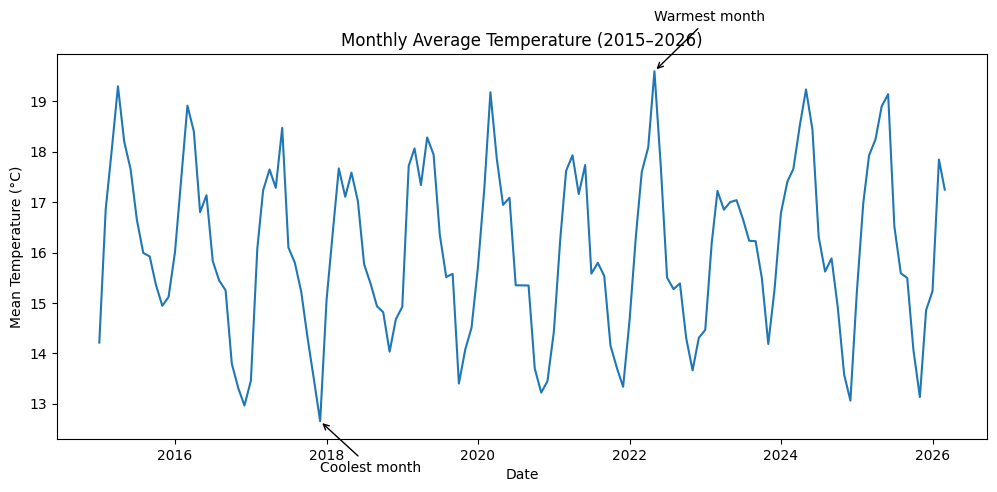

In [43]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_t2m["date"], monthly_t2m["T2M"])

# Warmest month
plt.annotate(
    "Warmest month",
    xy=(peak_tempMax["date"], peak_tempMax["T2M"]),
    xytext=(peak_tempMax["date"], peak_tempMax["T2M"] + 1),
    arrowprops=dict(arrowstyle="->")
)

# Coolest month
plt.annotate(
    "Coolest month",
    xy=(peak_tempMin["date"], peak_tempMin["T2M"]),
    xytext=(peak_tempMin["date"], peak_tempMin["T2M"] - 1),
    arrowprops=dict(arrowstyle="->")
)

plt.xlabel("Date")
plt.ylabel("Mean Temperature (°C)")
plt.title("Monthly Average Temperature (2015–2026)")

plt.show()

The temperature does not show any obvious unusual patterns, and the overall pattern remains relatively consistent. The mean and median are close to each other, suggesting that the temperature distribution is not strongly skewed. The annotated warmest and coolest months occur within the middle of the time period rather than at the beginning or end of the dataset, so the graph does not show a clear pattern of temperatures constantly increasing over the years.


In [34]:
monthly_prec=df.groupby(["Month"])["PRECTOTCORR"].sum().reset_index()

In [35]:
peak_rain = monthly_prec.loc[monthly_prec["PRECTOTCORR"].idxmax()]

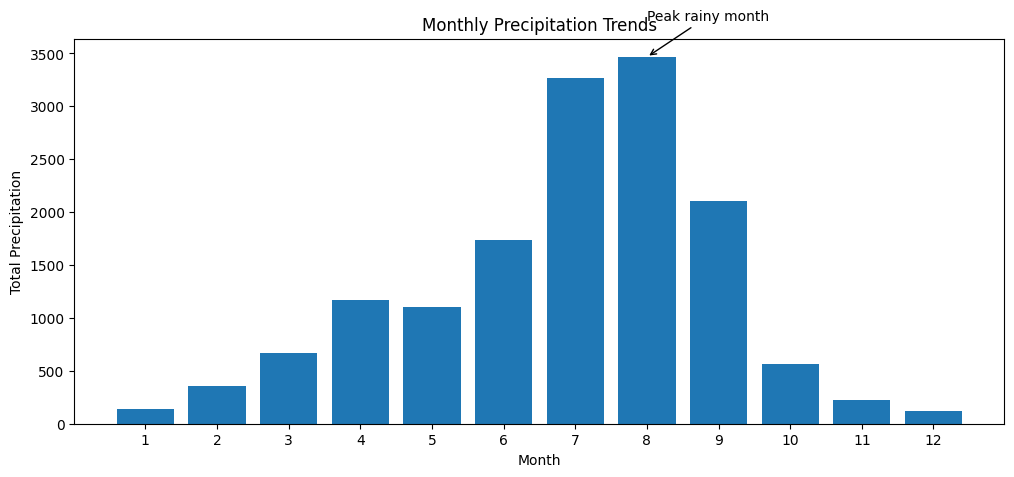

In [37]:
plt.figure(figsize=(12,5))
plt.bar(monthly_prec["Month"],monthly_prec["PRECTOTCORR"])
plt.annotate(
    "Peak rainy month",
    xy=(peak_rain["Month"], peak_rain["PRECTOTCORR"]),
    xytext=(peak_rain["Month"], peak_rain["PRECTOTCORR"] * 1.1),
    arrowprops=dict(arrowstyle="->")
)
plt.xlabel("Month")
plt.ylabel("Total Precipitation")
plt.title("Monthly Precipitation Trends")
plt.xticks(range(1, 13))
plt.show()

The rainfall pattern shows a clear seasonal variation. June, July, August, and September are the main rainy months, with substantially higher precipitation than the rest of the year. Outside of these months, precipitation is generally much lower, with some periods being almost dry. Overall, rainfall is strongly concentrated during the rainy season rather than being evenly distributed throughout the year.


In [44]:
number=df.select_dtypes(include="number")

In [45]:
correlation=number.corr()

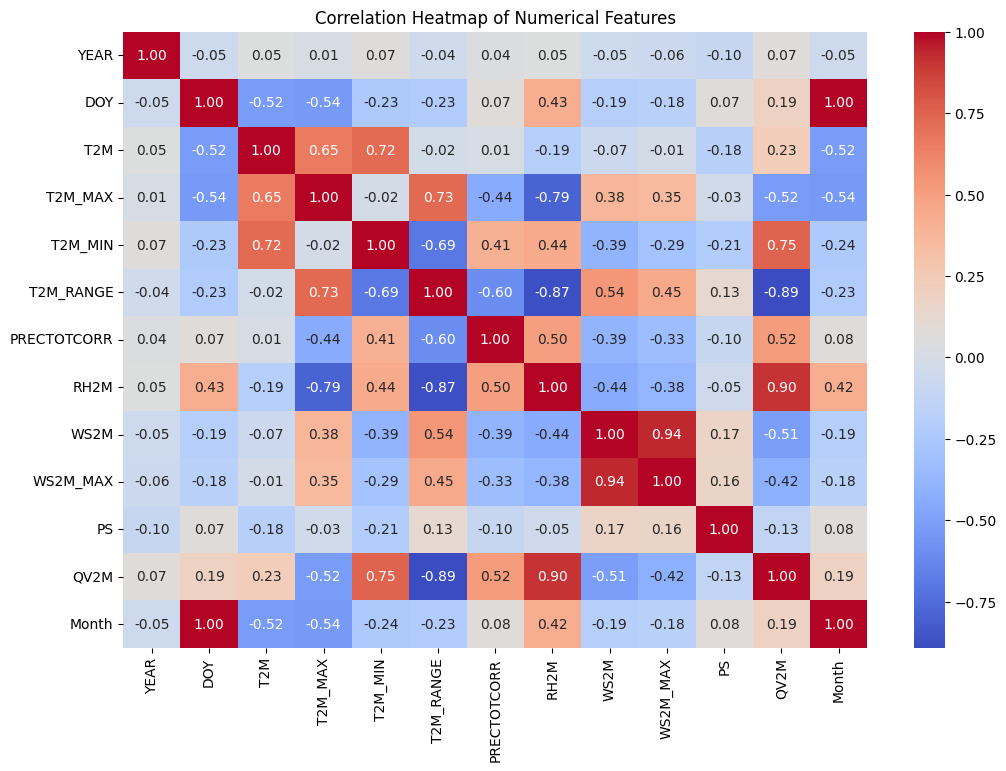

In [47]:
plt.figure(figsize=(12,8))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

RH2M vs QV2M with 0.9, WS2M VS WS2M_MAX=0.94, T2M_RANGE VS QV2M=-0.89 an opposite strong relation ship, T2M_RANGE VS RH2M =-0.87 shows a strong opposite relation as well still showing the close positive relation between RH2M and QV2M


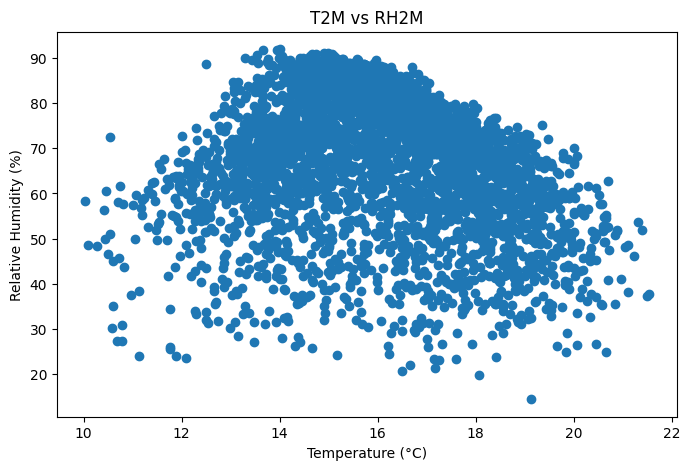

In [48]:
plt.figure(figsize=(8, 5))

plt.scatter(df["T2M"], df["RH2M"])

plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.title("T2M vs RH2M")

plt.show()

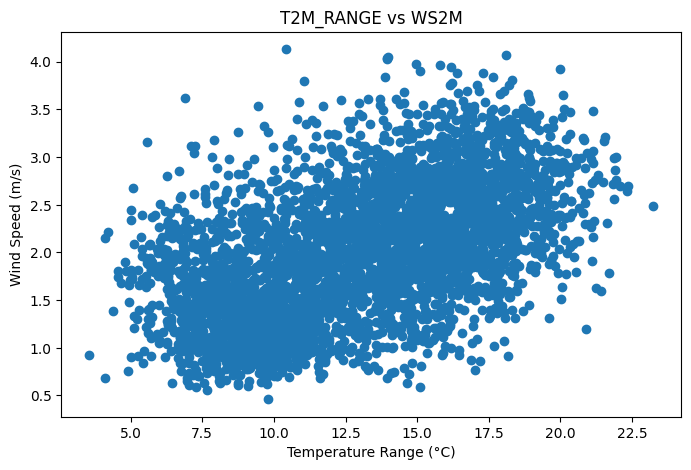

In [49]:
plt.figure(figsize=(8,5))
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.xlabel("Temperature Range (°C)")
plt.ylabel("Wind Speed (m/s)")
plt.title("T2M_RANGE vs WS2M")
plt.show()

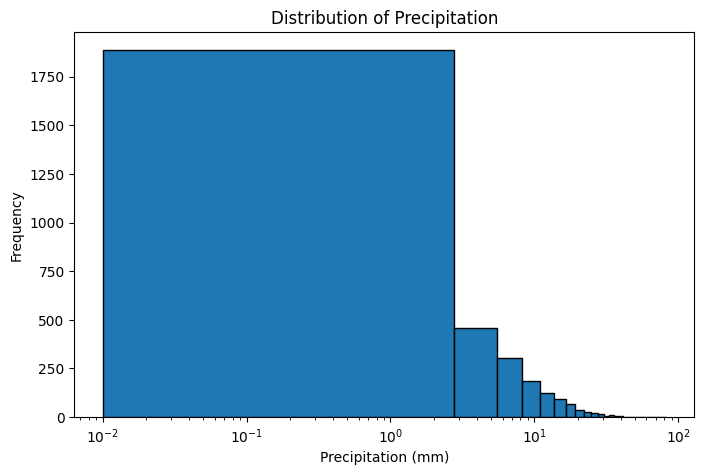

In [50]:
rain=df.loc[df["PRECTOTCORR"]>0, "PRECTOTCORR"]
plt.figure(figsize=(8,5))
plt.hist(rain, bins=30, edgecolor="black")
plt.xscale("log")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency")
plt.title("Distribution of Precipitation")
plt.show()

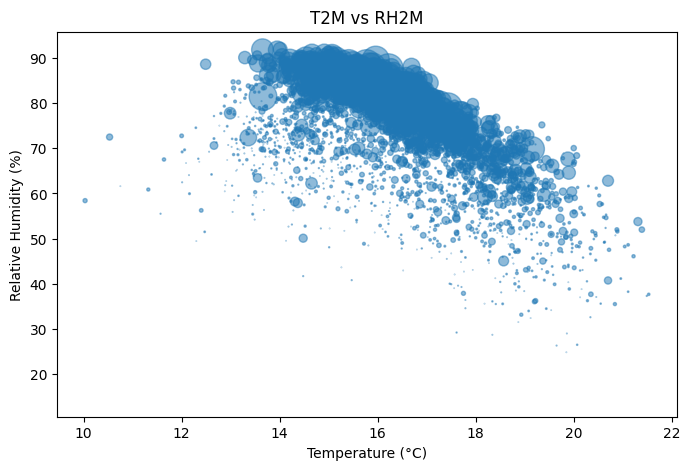

In [51]:
plt.figure(figsize=(8,5))
plt.scatter(df["T2M"],df["RH2M"], s=df["PRECTOTCORR"]*10, alpha=0.5 )
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.title("T2M vs RH2M")
plt.show()